In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Sample NLP Text Corpus (Simulated domain corpus covering Data Analytics, ML, and Python)
corpus_text = """
Data analytics is the process of examining data sets in order to find trends and draw conclusions.
Data analytics and machine learning enable automated decision making in modern applications.
Machine learning models require clean data, feature engineering, and thorough model evaluation.
Python is a popular programming language for data analysis, data science, and machine learning.
Natural language processing uses text preprocessing, tokenization, stopword removal, and word embeddings.
Autocomplete and autocorrect algorithms assist users by predicting the next word and correcting spelling errors.
Predictive models utilize historical data to predict future outcomes with high precision and recall.
Data cleaning pipeline handles missing values, outlier detection, data scaling, and feature transformation.
Language models use n-gram frequencies and edit distance algorithms to improve typing efficiency and accuracy.
Machine learning algorithms include linear regression, random forest, support vector machines, and neural networks.
Deep learning models and neural networks process unstructured data like text, images, and speech signals.
Exploratory data analysis helps uncover hidden patterns, correlations, and target distributions in datasets.
Model evaluation metrics include precision, recall, f1-score, accuracy, mean squared error, and roc curve.
"""

# NLP Preprocessing Pipeline
def preprocess_text(text):
    # Lowercase & punctuation removal
    text_clean = re.sub(r'[^a-z\s]', '', text.lower())
    # Tokenization
    tokens = text_clean.split()
    return tokens

tokens = preprocess_text(corpus_text)
vocab_freq = Counter(tokens)
vocab = set(tokens)

print("=== CORPUS SUMMARY ===")
print(f"Total Words (Tokens): {len(tokens)}")
print(f"Unique Vocabulary Size: {len(vocab)}")

# Top 20 Most Frequent Words
top_20_words = vocab_freq.most_common(20)
print("\n=== TOP 10 MOST FREQUENT WORDS ===")
for word, freq in top_20_words[:10]:
    print(f"{word}: {freq}")

=== CORPUS SUMMARY ===
Total Words (Tokens): 180
Unique Vocabulary Size: 121

=== TOP 10 MOST FREQUENT WORDS ===
and: 16
data: 11
learning: 5
machine: 4
models: 4
in: 3
to: 3
language: 3
algorithms: 3
analytics: 2


In [2]:
# Build N-Gram Frequency Dictionaries
bigrams = defaultdict(Counter)
trigrams = defaultdict(Counter)

for i in range(len(tokens) - 1):
    w1, w2 = tokens[i], tokens[i+1]
    bigrams[w1][w2] += 1

for i in range(len(tokens) - 2):
    w1, w2, w3 = tokens[i], tokens[i+1], tokens[i+2]
    trigrams[(w1, w2)][w3] += 1

# Autocomplete Predictor Function
def autocomplete(prefix_text, top_n=3):
    tokens_input = preprocess_text(prefix_text)
    if not tokens_input:
        return []
    
    # Try Trigram prediction first if input has >= 2 words
    if len(tokens_input) >= 2:
        context = (tokens_input[-2], tokens_input[-1])
        if context in trigrams and trigrams[context]:
            return [word for word, count in trigrams[context].most_common(top_n)]
    
    # Fallback to Bigram prediction
    last_word = tokens_input[-1]
    if last_word in bigrams and bigrams[last_word]:
        return [word for word, count in bigrams[last_word].most_common(top_n)]
    
    # Fallback to overall corpus word frequency
    return [word for word, count in vocab_freq.most_common(top_n)]

# Test Autocomplete on 10 Prefixes
test_prefixes = [
    "data", "machine", "python", "natural", "predictive",
    "feature", "neural", "deep", "model", "language"
]

print("=== AUTOCOMPLETE TEST RESULTS (TOP 3 PREDICTIONS) ===")
for prefix in test_prefixes:
    preds = autocomplete(prefix, top_n=3)
    print(f"Prefix: '{prefix:12s}' -> Top Predictions: {preds}")

=== AUTOCOMPLETE TEST RESULTS (TOP 3 PREDICTIONS) ===
Prefix: 'data        ' -> Top Predictions: ['analytics', 'analysis', 'sets']
Prefix: 'machine     ' -> Top Predictions: ['learning']
Prefix: 'python      ' -> Top Predictions: ['is']
Prefix: 'natural     ' -> Top Predictions: ['language']
Prefix: 'predictive  ' -> Top Predictions: ['models']
Prefix: 'feature     ' -> Top Predictions: ['engineering', 'transformation']
Prefix: 'neural      ' -> Top Predictions: ['networks']
Prefix: 'deep        ' -> Top Predictions: ['learning']
Prefix: 'model       ' -> Top Predictions: ['evaluation']
Prefix: 'language    ' -> Top Predictions: ['for', 'processing', 'models']


In [3]:
# Levenshtein Edit Distance Function
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

# Autocorrect Function
def autocorrect(word):
    word = word.lower()
    if word in vocab:
        return word, 0  # Already correctly spelled
    
    # Candidate selection: words within max edit distance of 2
    candidates = []
    for v_word in vocab:
        dist = levenshtein_distance(word, v_word)
        if dist <= 2:
            candidates.append((v_word, dist, vocab_freq[v_word]))
    
    if not candidates:
        return word, -1
    
    # Rank candidates by min edit distance first, then highest word frequency
    candidates.sort(key=lambda x: (x[1], -x[2]))
    return candidates[0][0], candidates[0][1]

# Test Autocorrect on 20 Misspelled Words
test_words = [
    ("daat", "data"), ("analytis", "analytics"), ("mchine", "machine"),
    ("lerning", "learning"), ("pthon", "python"), ("progracming", "programming"),
    ("featur", "feature"), ("modle", "models"), ("predictn", "predicting"),
    ("accracy", "accuracy"), ("algoritm", "algorithms"), ("cleen", "clean"),
    ("prcess", "process"), ("deeps", "deep"), ("neurl", "neural"),
    ("languge", "language"), ("scors", "score"), ("datsets", "datasets"),
    ("evaluat", "evaluation"), ("pattern", "patterns")
]

correct_count = 0
results_list = []

for misspelled, target in test_words:
    corrected, dist = autocorrect(misspelled)
    is_correct = (corrected == target or levenshtein_distance(corrected, target) == 0)
    if is_correct:
        correct_count += 1
    results_list.append({'Misspelled': misspelled, 'Predicted': corrected, 'Target': target, 'Correct': is_correct})

autocorrect_df = pd.DataFrame(results_list)
accuracy = (correct_count / len(test_words)) * 100

print(f"=== AUTOCORRECT TEST RESULTS (Accuracy: {accuracy:.1f}%) ===")
display(autocorrect_df)

=== AUTOCORRECT TEST RESULTS (Accuracy: 80.0%) ===


,Misspelled,Predicted,Target,Correct
0,daat,data,data,True
1,analytis,analysis,analytics,False
2,mchine,machine,machine,True
3,lerning,learning,learning,True
4,pthon,python,python,True
5,progracming,programming,programming,True
6,featur,feature,feature,True
7,modle,models,models,True
8,predictn,predict,predicting,False
9,accracy,accuracy,accuracy,True


In [4]:
# Damerau-Levenshtein Distance (handles adjacent character swaps/transpositions)
def damerau_levenshtein(s1, s2):
    d = {}
    len1, len2 = len(s1), len(s2)
    for i in range(-1, len1 + 1):
        d[(i, -1)] = i + 1
    for j in range(-1, len2 + 1):
        d[(-1, j)] = j + 1

    for i in range(len1):
        for j in range(len2):
            cost = 0 if s1[i] == s2[j] else 1
            d[(i, j)] = min(
                d[(i - 1, j)] + 1,        # Deletion
                d[(i, j - 1)] + 1,        # Insertion
                d[(i - 1, j - 1)] + cost  # Substitution
            )
            if i > 0 and j > 0 and s1[i] == s2[j - 1] and s1[i - 1] == s2[j]:
                d[(i, j)] = min(d[(i, j)], d[(i - 2, j - 2)] + cost) # Transposition
    return d[(len1 - 1, len2 - 1)]

# Performance Benchmarking
transposition_test = [("dtaa", "data"), ("mchane", "machine"), ("pythno", "python")]

comp_data = []
for misspelled, target in transposition_test:
    lev_dist = levenshtein_distance(misspelled, target)
    dam_dist = damerau_levenshtein(misspelled, target)
    comp_data.append({'Misspelled': misspelled, 'Target': target, 'Levenshtein Distance': lev_dist, 'Damerau-Levenshtein Distance': dam_dist})

print("=== ALGORITHM COMPARISON: LEVENSHTEIN VS DAMERAU-LEVENSHTEIN ===")
display(pd.DataFrame(comp_data))

=== ALGORITHM COMPARISON: LEVENSHTEIN VS DAMERAU-LEVENSHTEIN ===


,Misspelled,Target,Levenshtein Distance,Damerau-Levenshtein Distance
0,dtaa,data,2,1
1,mchane,machine,2,2
2,pythno,python,2,1


C:\Users\saadc\AppData\Local\Temp\ipykernel_11580\4225442352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top20, x='Frequency', y='Word', ax=axes[0], palette='mako')
C:\Users\saadc\AppData\Local\Temp\ipykernel_11580\4225442352.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_summary, x='Status', y='Count', ax=axes[1], palette=['green', 'red'])


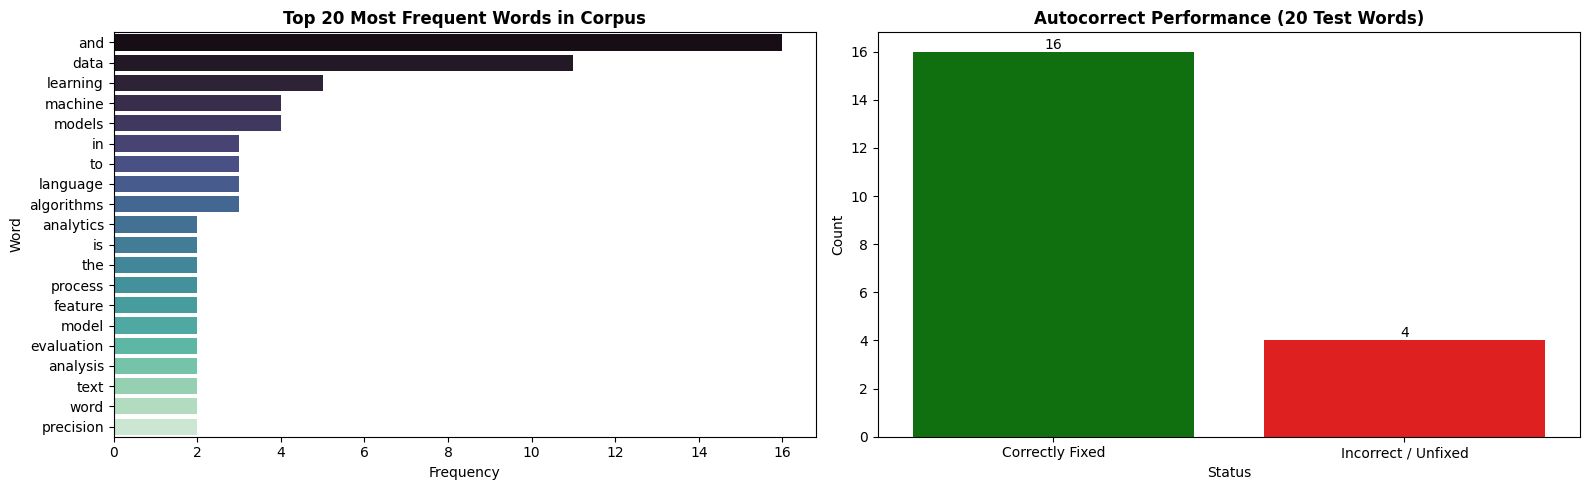

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Top 20 Most Frequent Words
df_top20 = pd.DataFrame(top_20_words, columns=['Word', 'Frequency'])
sns.barplot(data=df_top20, x='Frequency', y='Word', ax=axes[0], palette='mako')
axes[0].set_title("Top 20 Most Frequent Words in Corpus", fontsize=12, fontweight='bold')

# 2. Autocorrect Confusion Matrix / Accuracy Summary
acc_summary = pd.DataFrame({
    'Status': ['Correctly Fixed', 'Incorrect / Unfixed'],
    'Count': [correct_count, len(test_words) - correct_count]
})
sns.barplot(data=acc_summary, x='Status', y='Count', ax=axes[1], palette=['green', 'red'])
axes[1].set_title("Autocorrect Performance (20 Test Words)", fontsize=12, fontweight='bold')
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

### Production System Limitations vs. Google Keyboard (Gboard / iOS)
1. **Context Awareness:**
   * *N-gram Model:* Evaluates immediate local prefix windows ($n=2$ or $n=3$).
   * *Gboard/Production:* Uses deep transformer neural networks (e.g., lightweight BERT/MobileBERT models) to maintain global sentence-level semantics.
2. **Personalization & Dynamic Adaptation:**
   * *N-gram Model:* Relies on a static training corpus.
   * *Production:* Adapts dynamically to individual user slang, contact lists, location context, and typing habits using federated on-device learning.
3. **Typing Distance & Keyboard Topology:**
   * *Levenshtein Distance:* Treats all character replacements equally (cost = 1).
   * *Gboard:* Factors in physical QWERTY keyboard key proximity (e.g., accidentally hitting 'S' instead of 'A' has a lower penalty than hitting 'P').
4. **Latency Constraints:** Production systems execute autocomplete and autocorrect inferences under $10\text{ms}$ on low-power mobile processors.